# Run Simulation

In [1]:
import logging
logging.basicConfig(level=logging.DEBUG)
import sys
sys.path.insert(0, "/Users/ddw/Desktop/Rescheduling")
from run_simulation import run_simulation
from utils.metrics import compute_metrics

state, df, meta, _ = run_simulation(
    n_freight            = 182,
    trigger_strategy     = "periodic",
    event_driven_freq    = 900,
    mc_delay_per_train   = 40,
    controller_freq      = 450,
    periodic_freq        = 100000,
    threshold_confidence = 0.4,
    objective_strategy   = "static",
    upgrade_weight = 0,
    weight_passenger     = 1,
    weight_freight       = 1,
    dynamic_threshold    = 180,
    seed                 = 5,
    save                 = False,
)

if meta["deadlock_detected"]:
    print("DEADLOCK gedetecteerd — run incomplete, metrics niet beschikbaar.")
else:
    metrics = compute_metrics(df)
    print(f"TED_passenger : {metrics['TED_passenger']:,.0f}s")
    print(f"TED_freight   : {metrics['TED_freight']:,.0f}s")
    print(f"TED_combined  : {metrics['TED_combined']:,.0f}s")
    print(f"delay_ratio   : {metrics['delay_ratio']:.3f}" if metrics['delay_ratio'] else "delay_ratio   : N/A")
    print(f"n_rescheduled : {meta['controller_summary']['n_rescheduled']}")

INFO:data.timetable:Gold geladen (passenger): 1028 treinen, 10072 segmenten
INFO:data.timetable:Gold geladen (freight): 182 treinen, 734 segmenten
INFO:data.combine_timetable:Gecombineerd: 1210 treinen (1028 passenger, 182 freight), 10806 segmenten


Loading data...


INFO:data.loader:Treinen geladen: 1210
INFO:data.loader:Segmenten geladen: 132
INFO:data.loader:Timetable geladen: 10806 (train_no, segment_id) combinaties
INFO:data.running_distributions:Rijtijdverdelingen geladen: 100 secties
DEBUG:reality.sampling:Geen data voor (28:SCHAARBEEK-THURN EN TAXIS, freight, 0-0, NIGHT) — caller gebruikt geplande rijtijd
DEBUG:simulation.dispatcher:!! Als dit na de eerste reschedule is, fallback naar scheduled_departure voor dwell-segment: in simulatie, ervoor is dit normaal train=9272 seg=BRUSSEL-NOORD -- platform 9 fallback_exit=363.0
DEBUG:simulation.dispatcher:!! Als dit na de eerste reschedule is, fallback naar scheduled_departure voor dwell-segment: in simulatie, ervoor is dit normaal train=9272 seg=BRUSSEL-CENTRAAL -- platform 2 fallback_exit=663.0
DEBUG:simulation.dispatcher:!! Als dit na de eerste reschedule is, fallback naar scheduled_departure voor dwell-segment: in simulatie, ervoor is dit normaal train=1995 seg=BRUSSEL-NOORD -- platform 9 fall

Building controller (trigger=periodic, objective=static)...
Running simulation...


DEBUG:reality.sampling:Geen data voor (26:SCHAARBEEK-BRUSSEL-SCHUMAN, freight, 0-0, NIGHT) — caller gebruikt geplande rijtijd
DEBUG:simulation.dispatcher:!! Als dit na de eerste reschedule is, fallback naar scheduled_departure voor dwell-segment: in simulatie, ervoor is dit normaal train=1954 seg=BRUSSEL-NOORD -- platform 12 fallback_exit=20823.0
DEBUG:simulation.dispatcher:!! Als dit na de eerste reschedule is, fallback naar scheduled_departure voor dwell-segment: in simulatie, ervoor is dit normaal train=2254 seg=BRUSSEL-CENTRAAL -- platform 4 fallback_exit=20763.0
DEBUG:simulation.dispatcher:!! Als dit na de eerste reschedule is, fallback naar scheduled_departure voor dwell-segment: in simulatie, ervoor is dit normaal train=9211 seg=BRUSSEL-CENTRAAL -- platform 5 fallback_exit=20823.0
DEBUG:simulation.dispatcher:!! Als dit na de eerste reschedule is, fallback naar scheduled_departure voor dwell-segment: in simulatie, ervoor is dit normaal train=2075 seg=BRUSSEL-NOORD -- platform 1 f

Processing results...
Done. 10806 rows, 1210 trains.
Controller: {'n_rescheduled': 0, 'n_fcfs_fallback': 0, 'n_skipped': 11059, 'n_evaluated': 0, 'total_steps': 11059, 'total_solver_runtime_s': 0}
TED_passenger : 46,042s
TED_freight   : 17,240s
TED_combined  : 63,282s
delay_ratio   : 2.115
n_rescheduled : 0


In [2]:
import logging
logging.basicConfig(level=logging.DEBUG)

import sys
sys.path.insert(0, "/Users/ddw/Desktop/Rescheduling")

from run_simulation import run_simulation
from utils.metrics import compute_metrics
from data.loader import load_all


# ------------------------------------------------------------
# LOAD DOMAIN OBJECTS
# ------------------------------------------------------------

trains, segments, timetable = load_all(n_freight=182)


# ------------------------------------------------------------
# RUN SIMULATION
# ------------------------------------------------------------

state, df, meta, _ = run_simulation(
    n_freight            = 182,
    trigger_strategy     = "periodic",
    event_driven_freq    = 900,
    mc_delay_per_train   = 40,
    controller_freq      = 450,
    periodic_freq        = 900,
    threshold_confidence = 0.4,
    objective_strategy   = "static",
    upgrade_weight       = 0,
    weight_passenger     = 1,
    weight_freight       = 1,
    dynamic_threshold    = 180,
    seed                 = 5,
    save                 = False,
)


# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

if meta["deadlock_detected"]:
    print("DEADLOCK gedetecteerd — run incomplete, metrics niet beschikbaar.")
else:
    metrics = compute_metrics(df)

    print(f"TED_passenger : {metrics['TED_passenger']:,.0f}s")
    print(f"TED_freight   : {metrics['TED_freight']:,.0f}s")
    print(f"TED_combined  : {metrics['TED_combined']:,.0f}s")
    print(
        f"delay_ratio   : {metrics['delay_ratio']:.3f}"
        if metrics['delay_ratio']
        else "delay_ratio   : N/A"
    )
    print(f"n_rescheduled : {meta['controller_summary']['n_rescheduled']}")


# ------------------------------------------------------------
# DEBUG FUNCTION
# ------------------------------------------------------------

import pandas as pd


def compare_train(train_id, state, timetable, trains):

    rows = []

    train = trains[train_id]

    for seg in train.path:

        sched_entry = timetable.scheduled_entry(train_id, seg)
        sched_exit  = timetable.scheduled_exit(train_id, seg)

        try:
            actual_entry = state.actual_entry(train_id, seg)
        except KeyError:
            actual_entry = None

        try:
            actual_exit = state.actual_exit(train_id, seg)
        except KeyError:
            actual_exit = None

        entry_delay = (
            actual_entry - sched_entry
            if actual_entry is not None else None
        )

        exit_delay = (
            actual_exit - sched_exit
            if actual_exit is not None else None
        )

        rows.append({
            "segment": seg,
            "scheduled_entry": sched_entry,
            "actual_entry": actual_entry,
            "entry_delay": entry_delay,
            "scheduled_exit": sched_exit,
            "actual_exit": actual_exit,
            "exit_delay": exit_delay,
        })

    df_debug = pd.DataFrame(rows)

    numeric_cols = [
        "scheduled_entry",
        "actual_entry",
        "entry_delay",
        "scheduled_exit",
        "actual_exit",
        "exit_delay",
    ]

    df_debug[numeric_cols] = df_debug[numeric_cols].round(1)

    return df_debug


# ------------------------------------------------------------
# EXAMPLE
# ------------------------------------------------------------

display(compare_train(900000, state, timetable, trains))

INFO:data.timetable:Gold geladen (passenger): 1028 treinen, 10072 segmenten
INFO:data.timetable:Gold geladen (freight): 182 treinen, 734 segmenten
INFO:data.combine_timetable:Gecombineerd: 1210 treinen (1028 passenger, 182 freight), 10806 segmenten
INFO:data.loader:Treinen geladen: 1210
INFO:data.loader:Segmenten geladen: 132
INFO:data.loader:Timetable geladen: 10806 (train_no, segment_id) combinaties
INFO:data.timetable:Gold geladen (passenger): 1028 treinen, 10072 segmenten
INFO:data.timetable:Gold geladen (freight): 182 treinen, 734 segmenten
INFO:data.combine_timetable:Gecombineerd: 1210 treinen (1028 passenger, 182 freight), 10806 segmenten


Loading data...


INFO:data.loader:Treinen geladen: 1210
INFO:data.loader:Segmenten geladen: 132
INFO:data.loader:Timetable geladen: 10806 (train_no, segment_id) combinaties
DEBUG:reality.sampling:Geen data voor (28:SCHAARBEEK-THURN EN TAXIS, freight, 0-0, NIGHT) — caller gebruikt geplande rijtijd
DEBUG:simulation.dispatcher:!! Als dit na de eerste reschedule is, fallback naar scheduled_departure voor dwell-segment: in simulatie, ervoor is dit normaal train=9272 seg=BRUSSEL-NOORD -- platform 9 fallback_exit=363.0
DEBUG:simulation.dispatcher:!! Als dit na de eerste reschedule is, fallback naar scheduled_departure voor dwell-segment: in simulatie, ervoor is dit normaal train=9272 seg=BRUSSEL-CENTRAAL -- platform 2 fallback_exit=663.0
DEBUG:simulation.dispatcher:!! Als dit na de eerste reschedule is, fallback naar scheduled_departure voor dwell-segment: in simulatie, ervoor is dit normaal train=1995 seg=BRUSSEL-NOORD -- platform 9 fallback_exit=783.0
DEBUG:simulation.dispatcher:!! Als dit na de eerste resc

Building controller (trigger=periodic, objective=static)...
Running simulation...
Set parameter Username


INFO:gurobipy:Set parameter Username


...

DEBUG:reality.sampling:Geen data voor (26:BRUSSEL-SCHUMAN-SCHAARBEEK, freight, 0-0, EVENING) — caller gebruikt geplande rijtijd


[t=79175] T=89 S=103 conf=992 vars=3092 constr=4401 bin=992
[t=79175s] RESCHEDULED — status=optimal, objective=185.00, solver_runtime=0.05s
[t=80081] T=76 S=101 conf=764 vars=2588 constr=3619 bin=764
[t=80081s] RESCHEDULED — status=optimal, objective=710.70, solver_runtime=0.03s
[t=81003] T=63 S=99 conf=600 vars=2094 constr=2910 bin=600


DEBUG:reality.sampling:Fallback (drop period): (60:ZELLIK-JETTE, ('IC', 'L'), 0-0, EVENING)
DEBUG:reality.sampling:Geen data voor (28:THURN EN TAXIS-SCHAARBEEK, freight, 0-0, EVENING) — caller gebruikt geplande rijtijd
DEBUG:reality.sampling:Geen data voor (28:THURN EN TAXIS-SCHAARBEEK, freight, 0-0, NIGHT) — caller gebruikt geplande rijtijd
DEBUG:reality.sampling:Fallback (drop period): (36N:SCHAARBEEK-BRUSSEL-NOORD, ('IC', 'L'), 0-0, NIGHT)


[t=81003s] RESCHEDULED — status=optimal, objective=480.00, solver_runtime=0.03s
[t=81913] T=52 S=94 conf=386 vars=1541 constr=2083 bin=386
[t=81913s] RESCHEDULED — status=optimal, objective=292.00, solver_runtime=0.02s
[t=82826] T=37 S=88 conf=216 vars=1038 constr=1363 bin=216
[t=82826s] RESCHEDULED — status=optimal, objective=320.70, solver_runtime=0.01s
[t=83736] T=26 S=85 conf=97 vars=664 constr=844 bin=97
[t=83736s] RESCHEDULED — status=optimal, objective=484.00, solver_runtime=0.01s
[t=84650] T=16 S=67 conf=43 vars=394 constr=488 bin=43
[t=84650s] RESCHEDULED — status=optimal, objective=193.20, solver_runtime=0.00s
[t=85563] T=9 S=44 conf=10 vars=172 constr=198 bin=10
[t=85563s] RESCHEDULED — status=optimal, objective=194.20, solver_runtime=0.00s
[t=86463] T=5 S=25 conf=3 vars=87 constr=93 bin=3
[t=86463s] RESCHEDULED — status=optimal, objective=1482.50, solver_runtime=0.00s
[t=87708] T=1 S=8 conf=0 vars=24 constr=23 bin=0
[t=87708s] RESCHEDULED — status=optimal, objective=1402.50

,segment,scheduled_entry,actual_entry,entry_delay,scheduled_exit,actual_exit,exit_delay
0,28(1):BRUSSEL-ZUID-BRUSSEL-WEST,30756.0,30696.0,-60.0,31146.0,31066.5,-79.5
1,BRUSSEL-WEST,31146.0,31066.5,-79.5,31147.0,31067.5,-79.5
2,28(1):BRUSSEL-WEST-SIMONIS,31147.0,31067.5,-79.5,31238.0,31149.4,-88.6
3,SIMONIS,31238.0,31149.4,-88.6,31239.0,31150.4,-88.6
4,28(1):SIMONIS-THURN EN TAXIS,31239.0,31150.4,-88.6,31330.0,31330.0,0.0
5,THURN EN TAXIS,31330.0,31330.0,0.0,31331.0,31331.0,0.0
6,28:THURN EN TAXIS-SCHAARBEEK,31331.0,31331.0,0.0,31744.0,31744.0,0.0
7,SCHAARBEEK,31744.0,31744.0,0.0,31745.0,31745.0,0.0
8,36N:SCHAARBEEK-BRUSSEL-NOORD,31745.0,31745.0,0.0,31979.0,31990.7,11.7


In [3]:
display(compare_train(10, state, timetable, trains))

,segment,scheduled_entry,actual_entry,entry_delay,scheduled_exit,actual_exit,exit_delay
0,36N:SCHAARBEEK-BRUSSEL-NOORD,76863.0,76863.0,0.0,77043.0,77107.0,64.0
1,BRUSSEL-NOORD -- platform 3,77043.0,77107.0,64.0,77163.0,77227.0,64.0
2,0-2:BRUSSEL-NOORD-BRUSSEL-CONGRES,77163.0,77227.0,64.0,77283.0,77337.0,54.0
3,BRUSSEL-CONGRES -- platform 1,77283.0,77337.0,54.0,77284.0,77338.0,54.0
4,0-2:BRUSSEL-CONGRES-BRUSSEL-CENTRAAL,77284.0,77338.0,54.0,77343.0,77423.0,80.0
5,BRUSSEL-CENTRAAL -- platform 5,77343.0,77423.0,80.0,77344.0,77424.0,80.0
6,0-2:BRUSSEL-CENTRAAL-BRUSSEL-KAPELLEKERK,77344.0,77424.0,80.0,77463.0,77478.0,15.0
7,BRUSSEL-KAPELLEKERK -- platform 4,77463.0,77478.0,15.0,77464.0,77479.0,15.0
8,0-2:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,77464.0,77479.0,15.0,77583.0,77617.0,34.0


In [22]:
display(compare_train(10, state, timetable, trains))

,segment,scheduled_entry,actual_entry,entry_delay,scheduled_exit,actual_exit,exit_delay
0,36N:SCHAARBEEK-BRUSSEL-NOORD,76863.0,76863.0,0.0,77043.0,77107.0,64.0
1,BRUSSEL-NOORD -- platform 3,77043.0,77107.0,64.0,77163.0,77227.0,64.0
2,0-2:BRUSSEL-NOORD-BRUSSEL-CONGRES,77163.0,77227.0,64.0,77283.0,77337.0,54.0
3,BRUSSEL-CONGRES -- platform 1,77283.0,77337.0,54.0,77284.0,77338.0,54.0
4,0-2:BRUSSEL-CONGRES-BRUSSEL-CENTRAAL,77284.0,77338.0,54.0,77343.0,77423.0,80.0
5,BRUSSEL-CENTRAAL -- platform 5,77343.0,77423.0,80.0,77344.0,77424.0,80.0
6,0-2:BRUSSEL-CENTRAAL-BRUSSEL-KAPELLEKERK,77344.0,77424.0,80.0,77463.0,77478.0,15.0
7,BRUSSEL-KAPELLEKERK -- platform 4,77463.0,77478.0,15.0,77464.0,77479.0,15.0
8,0-2:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,77464.0,77479.0,15.0,77583.0,77617.0,34.0


In [5]:
display(compare_train(900003, state, timetable, trains))

,segment,scheduled_entry,actual_entry,entry_delay,scheduled_exit,actual_exit,exit_delay
0,36N:SCHAARBEEK-BRUSSEL-NOORD,20343.0,20283.0,-60.0,20577.0,20561.2,-15.8


DEBUG:matplotlib:matplotlib data path: /Users/ddw/Desktop/Rescheduling/venv/lib/python3.13/site-packages/matplotlib/mpl-data
DEBUG:matplotlib:CONFIGDIR=/Users/ddw/.matplotlib
DEBUG:matplotlib:interactive is False
DEBUG:matplotlib:platform is darwin
DEBUG:matplotlib:CACHEDIR=/Users/ddw/.matplotlib
DEBUG:matplotlib.font_manager:Using fontManager instance from /Users/ddw/.matplotlib/fontlist-v390.json
DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.font_manager:findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/Users/ddw/Desktop/Rescheduling/venv/lib/python3.13/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizFourSymBol.ttf', name='STIXSizeFourSym', style='normal', variant='normal', weight=700, stretch='normal', si

END DELAY STATISTICS

Passenger:
count    1028.000000
mean       40.986410
std        84.283837
min      -144.000000
25%         0.000000
50%        10.000000
75%        65.250000
max       620.300000
Name: entry_delay, dtype: float64

Freight:
count     182.000000
mean       39.304169
std       219.078069
min      -306.300000
25%       -60.000000
50%         0.000000
75%        83.500000
max      1373.900000
Name: entry_delay, dtype: float64


DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/System/Library/Fonts/Supplemental/NotoSansTagbanwa-Regular.ttf', name='Noto Sans Tagbanwa', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/System/Library/Fonts/Supplemental/STIXVarBol.otf', name='STIXVariants', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/System/Library/Fonts/Supplemental/Georgia Bold Italic.ttf', name='Georgia', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/System/Library/Fonts/Supplemental/Mishafi Gold.ttf', name='Mishafi Gold', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/Syst

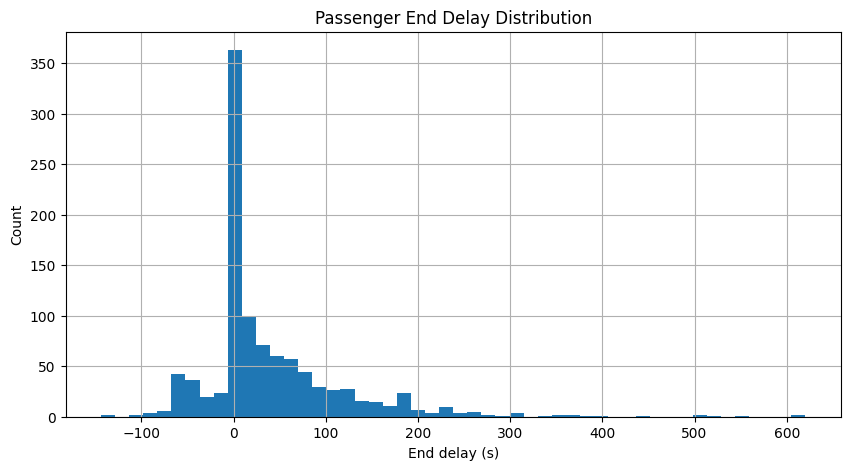

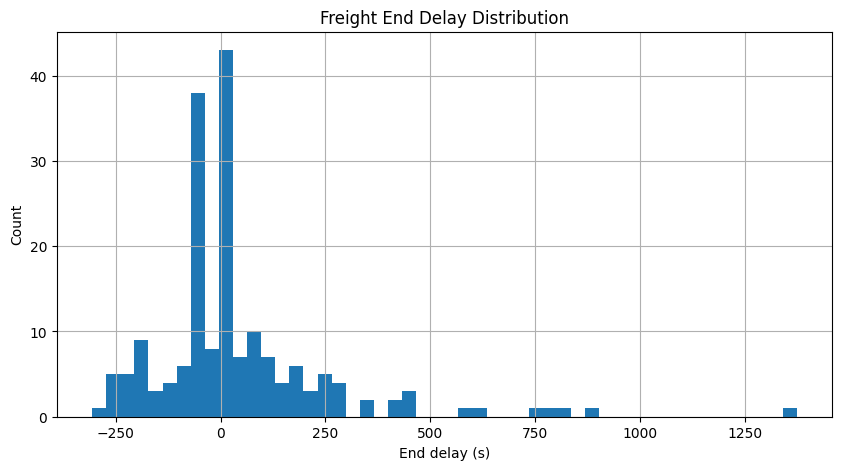


INTERMEDIATE DELAY STATISTICS

Passenger intermediate:
count    9044.000000
mean       18.677789
std        74.284943
min      -175.000000
25%       -16.000000
50%         0.000000
75%        34.000000
max       660.000000
Name: entry_delay, dtype: float64

Freight intermediate:
count     552.000000
mean      -31.093478
std       201.777757
min      -306.300000
25%      -108.100000
50%       -67.800000
75%        -9.100000
max      1402.500000
Name: entry_delay, dtype: float64


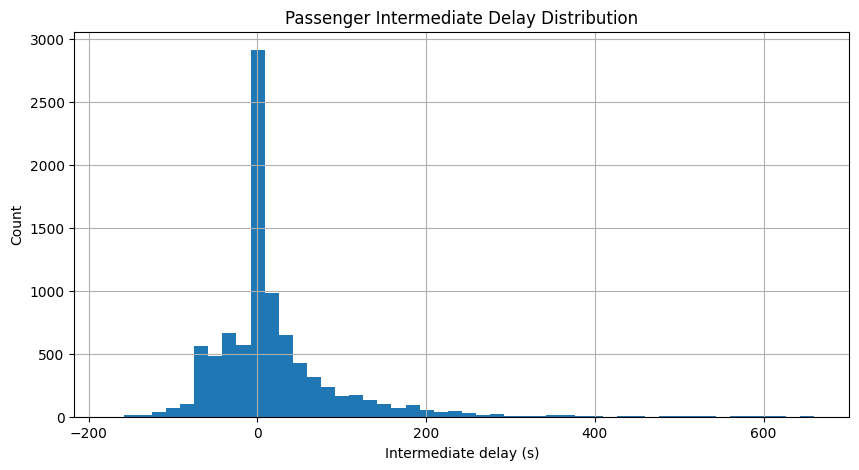

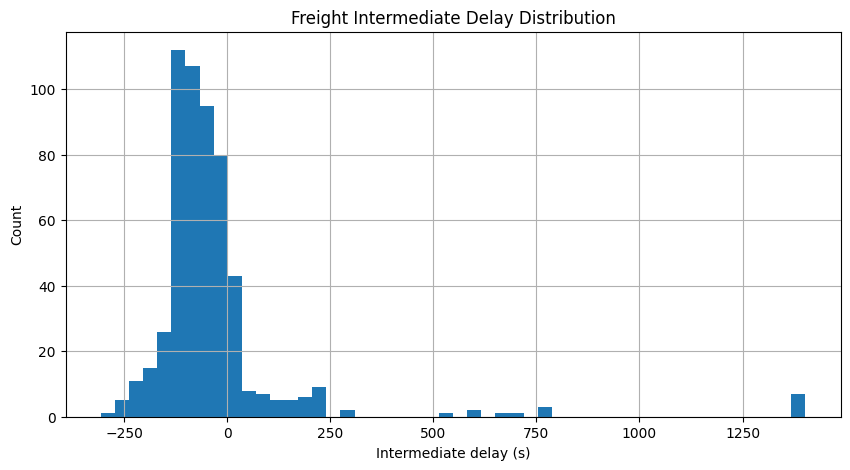


SIGN ANALYSIS

Passenger END
-------------
Negative :    140 ( 13.6%)
Zero     :    305 ( 29.7%)
Positive :    583 ( 56.7%)

Freight END
-----------
Negative :     79 ( 43.4%)
Zero     :     32 ( 17.6%)
Positive :     71 ( 39.0%)

Passenger INTERMEDIATE
----------------------
Negative :   2960 ( 32.7%)
Zero     :   1846 ( 20.4%)
Positive :   4238 ( 46.9%)

Freight INTERMEDIATE
--------------------
Negative :    431 ( 78.1%)
Zero     :     21 (  3.8%)
Positive :    100 ( 18.1%)


In [6]:
# ------------------------------------------------------------
# DELAY DISTRIBUTION ANALYSIS
# ------------------------------------------------------------

import matplotlib.pyplot as plt
import pandas as pd


# ============================================================
# 1. END DELAY DISTRIBUTIONS
# ============================================================

# Laatste segment per trein
last_seg = (
    df.sort_values("planned_entry")
      .groupby(["train_id", "train_type"])
      .last()
      .reset_index()
)

pass_end = last_seg[last_seg["train_type"] == "P"]["entry_delay"]
freight_end = last_seg[last_seg["train_type"] == "F"]["entry_delay"]

print("==================================================")
print("END DELAY STATISTICS")
print("==================================================")

print("\nPassenger:")
print(pass_end.describe())

print("\nFreight:")
print(freight_end.describe())


# Histogram passenger
plt.figure(figsize=(10, 5))
plt.hist(pass_end, bins=50)
plt.title("Passenger End Delay Distribution")
plt.xlabel("End delay (s)")
plt.ylabel("Count")
plt.grid(True)
plt.show()


# Histogram freight
plt.figure(figsize=(10, 5))
plt.hist(freight_end, bins=50)
plt.title("Freight End Delay Distribution")
plt.xlabel("End delay (s)")
plt.ylabel("Count")
plt.grid(True)
plt.show()


# ============================================================
# 2. INTERMEDIATE DELAY DISTRIBUTIONS
# ============================================================

# Intermediate = alle segmenten behalve laatste segment
last_pairs = set(
    zip(last_seg["train_id"], last_seg["segment_id"])
)

intermediate_df = df[
    ~df.apply(
        lambda r: (r["train_id"], r["segment_id"]) in last_pairs,
        axis=1
    )
]

pass_inter = intermediate_df[
    intermediate_df["train_type"] == "P"
]["entry_delay"]

freight_inter = intermediate_df[
    intermediate_df["train_type"] == "F"
]["entry_delay"]

print("\n==================================================")
print("INTERMEDIATE DELAY STATISTICS")
print("==================================================")

print("\nPassenger intermediate:")
print(pass_inter.describe())

print("\nFreight intermediate:")
print(freight_inter.describe())


# Histogram passenger intermediate
plt.figure(figsize=(10, 5))
plt.hist(pass_inter, bins=50)
plt.title("Passenger Intermediate Delay Distribution")
plt.xlabel("Intermediate delay (s)")
plt.ylabel("Count")
plt.grid(True)
plt.show()


# Histogram freight intermediate
plt.figure(figsize=(10, 5))
plt.hist(freight_inter, bins=50)
plt.title("Freight Intermediate Delay Distribution")
plt.xlabel("Intermediate delay (s)")
plt.ylabel("Count")
plt.grid(True)
plt.show()


# ============================================================
# 3. NEGATIVE VS POSITIVE DELAYS
# ============================================================

def summarize_signs(series, label):

    neg = (series < 0).sum()
    zero = (series == 0).sum()
    pos = (series > 0).sum()

    total = len(series)

    print(f"\n{label}")
    print("-" * len(label))

    print(f"Negative : {neg:6d} ({100*neg/total:5.1f}%)")
    print(f"Zero     : {zero:6d} ({100*zero/total:5.1f}%)")
    print(f"Positive : {pos:6d} ({100*pos/total:5.1f}%)")


print("\n==================================================")
print("SIGN ANALYSIS")
print("==================================================")

summarize_signs(pass_end, "Passenger END")
summarize_signs(freight_end, "Freight END")

summarize_signs(pass_inter, "Passenger INTERMEDIATE")
summarize_signs(freight_inter, "Freight INTERMEDIATE")

In [7]:
# ------------------------------------------------------------
# TOP DELAYED TRAINS
# ------------------------------------------------------------

top_pass = (
    last_seg[last_seg["train_type"] == "P"]
    .sort_values("entry_delay", ascending=False)
    .head(10)
)

top_freight = (
    last_seg[last_seg["train_type"] == "F"]
    .sort_values("entry_delay", ascending=False)
    .head(10)
)

print("TOP PASSENGER")
display(
    top_pass[
        ["train_id", "segment_id", "entry_delay"]
    ]
)

print("\nTOP FREIGHT")
display(
    top_freight[
        ["train_id", "segment_id", "entry_delay"]
    ]
)

TOP PASSENGER


,train_id,segment_id,entry_delay
983,9328,0-2:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,620.300000
30,427,0-2:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,617.000000
1000,9426,0-2:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,553.452913
771,3732,0-2:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,525.000000
551,2832,0-2:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,512.452913
625,3232,0-2:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,503.452913
408,2232,50C:BRUSSEL-ZUID-ANDERLECHT,446.300000
552,2833,0-2:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,398.600000
883,4513,25:BRUSSEL-NOORD-SCHAARBEEK,391.000000
879,4509,25:BRUSSEL-NOORD-SCHAARBEEK,364.400000



TOP FREIGHT


,train_id,segment_id,entry_delay
1126,900098,36N:SCHAARBEEK-BRUSSEL-NOORD,1373.9
1190,900162,36N:SCHAARBEEK-BRUSSEL-NOORD,903.0
1135,900107,36N:SCHAARBEEK-BRUSSEL-NOORD,815.1
1069,900041,36N:SCHAARBEEK-BRUSSEL-NOORD,787.2
1085,900057,36N:SCHAARBEEK-BRUSSEL-NOORD,765.4
1177,900149,28(1):BRUSSEL-WEST-BRUSSEL-ZUID,602.6
1111,900083,36N:SCHAARBEEK-BRUSSEL-NOORD,573.6
1099,900071,36N:SCHAARBEEK-BRUSSEL-NOORD,465.5
1052,900024,36N:SCHAARBEEK-BRUSSEL-NOORD,450.4
1077,900049,36N:SCHAARBEEK-BRUSSEL-NOORD,437.4


In [8]:
# ------------------------------------------------------------
# MEAN DELAY PER SEGMENT
# ------------------------------------------------------------

segment_delay = (
    df.groupby(["segment_id", "train_type"])["entry_delay"]
      .mean()
      .reset_index()
)

print("PASSENGER")
display(
    segment_delay[
        segment_delay["train_type"] == "P"
    ]
    .sort_values("entry_delay", ascending=False)
    .head(20)
)

print("\nFREIGHT")
display(
    segment_delay[
        segment_delay["train_type"] == "F"
    ]
    .sort_values("entry_delay", ascending=False)
    .head(20)
)

PASSENGER


,segment_id,train_type,entry_delay
125,BRUSSEL-ZUID -- IC 20: LIEGE-GUILLEMINS -> KNOKKE,P,126.200000
118,BRUSSEL-ZUID -- IC 05: CHARLEROI-CENTRAL -> AN...,P,108.444444
4,0-2:BRUSSEL-CENTRAAL-BRUSSEL-KAPELLEKERK,P,84.362018
74,50A:BRUSSEL-ZUID-ANDERLECHT,P,74.400000
6,0-2:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,P,65.938428
78,50C:BRUSSEL-ZUID-ANDERLECHT,P,64.506094
5,0-2:BRUSSEL-CONGRES-BRUSSEL-CENTRAAL,P,60.929530
113,BRUSSEL-ZUID -- IC 01: EUPEN -> OOSTENDE,P,60.250000
105,BRUSSEL-NOORD -- platform 3,P,58.650801
28,161-2:BRUSSEL-NOORD-SCHAARBEEK,P,57.437500



FREIGHT


,segment_id,train_type,entry_delay
59,36N:SCHAARBEEK-BRUSSEL-NOORD,F,133.153632
77,50C:BRUSSEL-ZUID-ANDERLECHT,F,74.000000
50,28(1):THURN EN TAXIS-SIMONIS,F,37.009677
52,28:SCHAARBEEK-THURN EN TAXIS,F,14.829032
31,25:BRUSSEL-NOORD-SCHAARBEEK,F,3.186076
145,THURN EN TAXIS,F,0.149254
66,50:BRUSSEL-NOORD-BOCKSTAEL,F,0.000000
141,SCHAARBEEK,F,-5.664179
53,28:THURN EN TAXIS-SCHAARBEEK,F,-27.369444
47,28(1):SIMONIS-THURN EN TAXIS,F,-38.855556


In [9]:
# ------------------------------------------------------------
# DELAY RATIO WITHOUT SCHAARBEEK -> BRUSSEL-NOORD
# ------------------------------------------------------------

import pandas as pd


# ============================================================
# 1. REMOVE TARGET SEGMENT
# ============================================================

excluded_segment = "36N:SCHAARBEEK-BRUSSEL-NOORD"

df_filtered = df[
    df["segment_id"] != excluded_segment
].copy()


# ============================================================
# 2. RECOMPUTE END DELAYS
# ============================================================

# Nieuwe "laatste segmenten" nadat het segment verwijderd is
last_seg_filtered = (
    df_filtered
    .sort_values("planned_entry")
    .groupby(["train_id", "train_type"])
    .last()
    .reset_index()
)

pass_mask = last_seg_filtered["train_type"] == "P"
freight_mask = last_seg_filtered["train_type"] == "F"

ted_p = (
    last_seg_filtered[pass_mask]["entry_delay"]
    .clip(lower=0)
    .sum()
)

ted_f = (
    last_seg_filtered[freight_mask]["entry_delay"]
    .clip(lower=0)
    .sum()
)

n_pass = pass_mask.sum()
n_freight = freight_mask.sum()

avg_p = ted_p / n_pass
avg_f = ted_f / n_freight

delay_ratio_filtered = avg_f / avg_p


# ============================================================
# 3. ORIGINAL METRICS
# ============================================================

orig = compute_metrics(df)

print("==================================================")
print("ORIGINAL")
print("==================================================")

print(f"TED_passenger : {orig['TED_passenger']:.1f}")
print(f"TED_freight   : {orig['TED_freight']:.1f}")
print(f"delay_ratio   : {orig['delay_ratio']:.3f}")

print("\n==================================================")
print("WITHOUT SCHAARBEEK -> BRUSSEL-NOORD")
print("==================================================")

print(f"TED_passenger : {ted_p:.1f}")
print(f"TED_freight   : {ted_f:.1f}")
print(f"delay_ratio   : {delay_ratio_filtered:.3f}")


# ============================================================
# 4. IMPACT ANALYSIS
# ============================================================

print("\n==================================================")
print("IMPACT")
print("==================================================")

delta = delay_ratio_filtered - orig["delay_ratio"]

print(f"Absolute change : {delta:+.3f}")
print(f"Relative change : {100 * delta / orig['delay_ratio']:+.1f}%")

ORIGINAL
TED_passenger : 48497.4
TED_freight   : 15433.2
delay_ratio   : 1.797

WITHOUT SCHAARBEEK -> BRUSSEL-NOORD
TED_passenger : 48497.4
TED_freight   : 4538.1
delay_ratio   : 0.723

IMPACT
Absolute change : -1.074
Relative change : -59.8%


BASELINE
delay_ratio = 1.797

TOP IMPACT SEGMENTS


,segment_id,new_delay_ratio,delta_ratio,abs_impact
0,36N:SCHAARBEEK-BRUSSEL-NOORD,0.723265,-1.074191,1.074191
1,25:BRUSSEL-NOORD-SCHAARBEEK,2.412272,0.614817,0.614817
2,28(1):BRUSSEL-WEST-BRUSSEL-ZUID,1.704357,-0.093099,0.093099
3,26:SCHAARBEEK-BRUSSEL-SCHUMAN,1.858732,0.061277,0.061277
4,50C:BRUSSEL-ZUID-ANDERLECHT,1.842540,0.045084,0.045084
5,0-2:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,1.840952,0.043496,0.043496
6,26:BRUSSEL-SCHUMAN-SCHAARBEEK,1.817427,0.019972,0.019972
7,50:BRUSSEL-NOORD-SCHAARBEEK,1.813950,0.016495,0.016495
8,0-4:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,1.811839,0.014383,0.014383
9,50C:ANDERLECHT-BRUSSEL-ZUID,1.810356,0.012900,0.012900


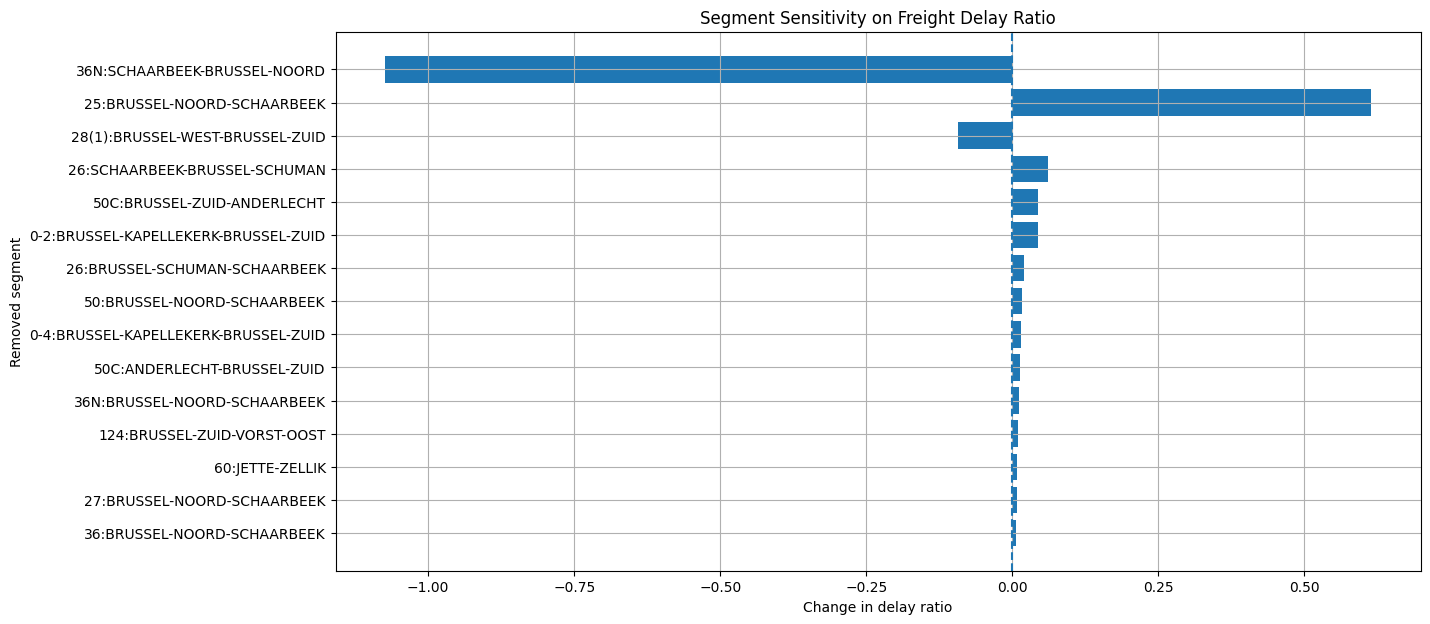

In [10]:
# ------------------------------------------------------------
# SEGMENT SENSITIVITY ANALYSIS
# ------------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# BASELINE
# ============================================================

baseline = compute_metrics(df)

baseline_ratio = baseline["delay_ratio"]

print("==================================================")
print("BASELINE")
print("==================================================")

print(f"delay_ratio = {baseline_ratio:.3f}")


# ============================================================
# FUNCTION
# ============================================================

def recompute_delay_ratio_without_segment(df, excluded_segment):

    # verwijder segment
    df_filtered = df[df["segment_id"] != excluded_segment].copy()

    # bepaal nieuw laatste segment per trein
    last_seg = (
        df_filtered
        .sort_values("planned_entry")
        .groupby(["train_id", "train_type"])
        .last()
        .reset_index()
    )

    pass_mask = last_seg["train_type"] == "P"
    freight_mask = last_seg["train_type"] == "F"

    ted_p = (
        last_seg[pass_mask]["entry_delay"]
        .clip(lower=0)
        .sum()
    )

    ted_f = (
        last_seg[freight_mask]["entry_delay"]
        .clip(lower=0)
        .sum()
    )

    n_pass = pass_mask.sum()
    n_freight = freight_mask.sum()

    if n_pass == 0 or n_freight == 0:
        return None

    avg_p = ted_p / n_pass

    if avg_p <= 0:
        return None

    avg_f = ted_f / n_freight

    return avg_f / avg_p


# ============================================================
# ANALYZE ALL SEGMENTS
# ============================================================

results = []

segments = sorted(df["segment_id"].unique())

for seg in segments:

    try:
        new_ratio = recompute_delay_ratio_without_segment(df, seg)

        if new_ratio is None:
            continue

        delta = new_ratio - baseline_ratio

        results.append({
            "segment_id": seg,
            "new_delay_ratio": new_ratio,
            "delta_ratio": delta,
            "abs_impact": abs(delta),
        })

    except Exception as e:

        print(f"FAILED for {seg}: {e}")


# ============================================================
# RESULTS TABLE
# ============================================================

sensitivity_df = (
    pd.DataFrame(results)
    .sort_values("abs_impact", ascending=False)
    .reset_index(drop=True)
)

print("\n==================================================")
print("TOP IMPACT SEGMENTS")
print("==================================================")

display(sensitivity_df.head(20))


# ============================================================
# PLOT
# ============================================================

top_plot = sensitivity_df.head(15)

plt.figure(figsize=(14, 7))

plt.barh(
    top_plot["segment_id"][::-1],
    top_plot["delta_ratio"][::-1],
)

plt.axvline(0, linestyle="--")

plt.xlabel("Change in delay ratio")
plt.ylabel("Removed segment")
plt.title("Segment Sensitivity on Freight Delay Ratio")

plt.grid(True)

plt.show()

BASELINE
TED_combined = 63930.5

TOP IMPACT SEGMENTS ON TOTAL END DELAY


,segment_id,new_TED_combined,delta_TED,abs_impact
0,36N:SCHAARBEEK-BRUSSEL-NOORD,53035.476221,-10895.052913,10895.052913
1,25:BRUSSEL-NOORD-SCHAARBEEK,61757.229134,-2173.300000,2173.300000
2,50C:BRUSSEL-ZUID-ANDERLECHT,62335.176221,-1595.352913,1595.352913
3,28(1):BRUSSEL-WEST-BRUSSEL-ZUID,62674.129134,-1256.400000,1256.400000
4,0-2:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,62784.676221,-1145.852913,1145.852913
5,50:BRUSSEL-NOORD-SCHAARBEEK,63489.529134,-441.000000,441.000000
6,0-4:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,63545.529134,-385.000000,385.000000
7,36N:BRUSSEL-NOORD-SCHAARBEEK,63631.529134,-299.000000,299.000000
8,124:BRUSSEL-ZUID-VORST-OOST,63677.529134,-253.000000,253.000000
9,60:JETTE-ZELLIK,63686.229134,-244.300000,244.300000


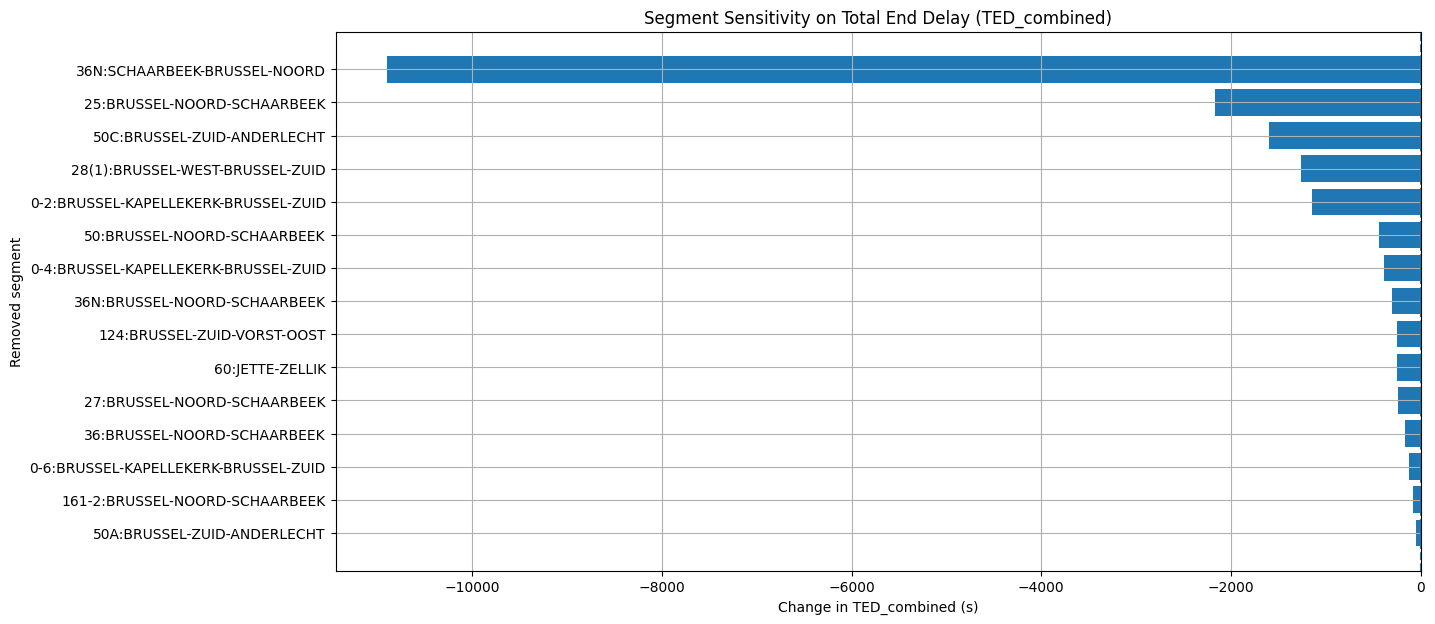

In [11]:
# ------------------------------------------------------------
# SEGMENT SENSITIVITY ANALYSIS ON TOTAL END DELAY
# ------------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# BASELINE
# ============================================================

baseline = compute_metrics(df)

baseline_ted = baseline["TED_combined"]

print("==================================================")
print("BASELINE")
print("==================================================")

print(f"TED_combined = {baseline_ted:.1f}")


# ============================================================
# FUNCTION
# ============================================================

def recompute_ted_without_segment(df, excluded_segment):

    # verwijder segment
    df_filtered = df[df["segment_id"] != excluded_segment].copy()

    # nieuw laatste segment per trein
    last_seg = (
        df_filtered
        .sort_values("planned_entry")
        .groupby(["train_id", "train_type"])
        .last()
        .reset_index()
    )

    ted_p = (
        last_seg[last_seg["train_type"] == "P"]["entry_delay"]
        .clip(lower=0)
        .sum()
    )

    ted_f = (
        last_seg[last_seg["train_type"] == "F"]["entry_delay"]
        .clip(lower=0)
        .sum()
    )

    return ted_p + ted_f


# ============================================================
# ANALYZE ALL SEGMENTS
# ============================================================

results = []

segments = sorted(df["segment_id"].unique())

for seg in segments:

    try:

        new_ted = recompute_ted_without_segment(df, seg)

        delta = new_ted - baseline_ted

        results.append({
            "segment_id": seg,
            "new_TED_combined": new_ted,
            "delta_TED": delta,
            "abs_impact": abs(delta),
        })

    except Exception as e:

        print(f"FAILED for {seg}: {e}")


# ============================================================
# RESULTS TABLE
# ============================================================

sensitivity_ted_df = (
    pd.DataFrame(results)
    .sort_values("abs_impact", ascending=False)
    .reset_index(drop=True)
)

print("\n==================================================")
print("TOP IMPACT SEGMENTS ON TOTAL END DELAY")
print("==================================================")

display(sensitivity_ted_df.head(20))


# ============================================================
# PLOT
# ============================================================

top_plot = sensitivity_ted_df.head(15)

plt.figure(figsize=(14, 7))

plt.barh(
    top_plot["segment_id"][::-1],
    top_plot["delta_TED"][::-1],
)

plt.axvline(0, linestyle="--")

plt.xlabel("Change in TED_combined (s)")
plt.ylabel("Removed segment")

plt.title(
    "Segment Sensitivity on Total End Delay (TED_combined)"
)

plt.grid(True)

plt.show()

TOP SEGMENTS BY MEAN DELAY


,Freight,Passenger,Combined
segment_id,,,
36N:SCHAARBEEK-BRUSSEL-NOORD,133.153632,34.154298,167.307930
50C:BRUSSEL-ZUID-ANDERLECHT,74.000000,64.506094,138.506094
BRUSSEL-ZUID -- IC 20: LIEGE-GUILLEMINS -> KNOKKE,0.000000,126.200000,126.200000
BRUSSEL-ZUID -- IC 05: CHARLEROI-CENTRAL -> ANTWERPEN-CENTRAAL,0.000000,108.444444,108.444444
0-2:BRUSSEL-CENTRAAL-BRUSSEL-KAPELLEKERK,0.000000,84.362018,84.362018
50A:BRUSSEL-ZUID-ANDERLECHT,0.000000,74.400000,74.400000
0-2:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,0.000000,65.938428,65.938428
0-2:BRUSSEL-CONGRES-BRUSSEL-CENTRAAL,0.000000,60.929530,60.929530
BRUSSEL-ZUID -- IC 01: EUPEN -> OOSTENDE,0.000000,60.250000,60.250000


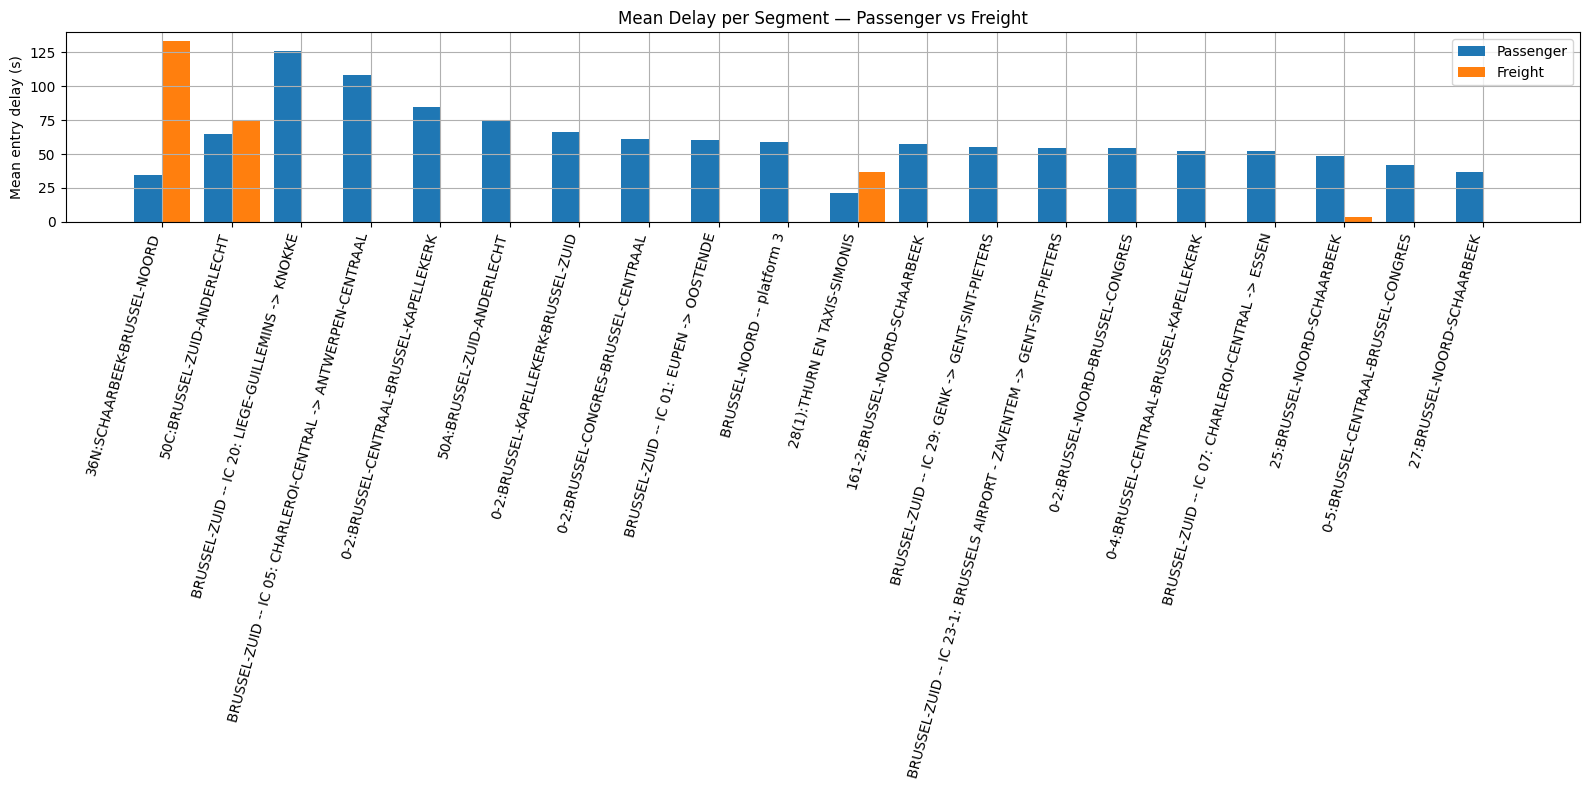

In [12]:
# ------------------------------------------------------------
# MEAN DELAY PER SEGMENT (PASSENGER VS FREIGHT)
# ------------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# MEAN DELAY PER SEGMENT & TRAIN TYPE
# ============================================================

segment_delay = (
    df.groupby(["segment_id", "train_type"])["entry_delay"]
      .mean()
      .reset_index()
)

# pivot zodat passenger/freight aparte kolommen worden
pivot = (
    segment_delay
    .pivot(
        index="segment_id",
        columns="train_type",
        values="entry_delay"
    )
    .fillna(0)
)

pivot.columns.name = None

# hernoem kolommen indien aanwezig
pivot = pivot.rename(columns={
    "P": "Passenger",
    "F": "Freight",
})

# totale gemiddelde delay
pivot["Combined"] = pivot.sum(axis=1)

# sorteer op totale impact
pivot = (
    pivot.sort_values("Combined", ascending=False)
         .head(20)
)

print("==================================================")
print("TOP SEGMENTS BY MEAN DELAY")
print("==================================================")

display(pivot)


# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(16, 8))

x = range(len(pivot))

width = 0.4

ax.bar(
    [i - width/2 for i in x],
    pivot["Passenger"],
    width=width,
    label="Passenger",
)

ax.bar(
    [i + width/2 for i in x],
    pivot["Freight"],
    width=width,
    label="Freight",
)

ax.set_xticks(list(x))
ax.set_xticklabels(
    pivot.index,
    rotation=75,
    ha="right"
)

ax.set_ylabel("Mean entry delay (s)")
ax.set_title("Mean Delay per Segment — Passenger vs Freight")

ax.legend()

ax.grid(True)

plt.tight_layout()
plt.show()

TOP FINAL SEGMENTS BY MEAN END DELAY


,Freight,Passenger,Combined
segment_id,,,
50C:BRUSSEL-ZUID-ANDERLECHT,74.000000,64.506094,138.506094
36N:SCHAARBEEK-BRUSSEL-NOORD,133.153632,0.000000,133.153632
50A:BRUSSEL-ZUID-ANDERLECHT,0.000000,74.400000,74.400000
0-2:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,0.000000,70.970622,70.970622
161-2:BRUSSEL-NOORD-SCHAARBEEK,0.000000,57.437500,57.437500
25:BRUSSEL-NOORD-SCHAARBEEK,-4.033333,48.189423,44.156090
27:BRUSSEL-NOORD-SCHAARBEEK,0.000000,37.058824,37.058824
0-4:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,0.000000,35.399174,35.399174
36:BRUSSEL-NOORD-SCHAARBEEK,0.000000,34.593939,34.593939


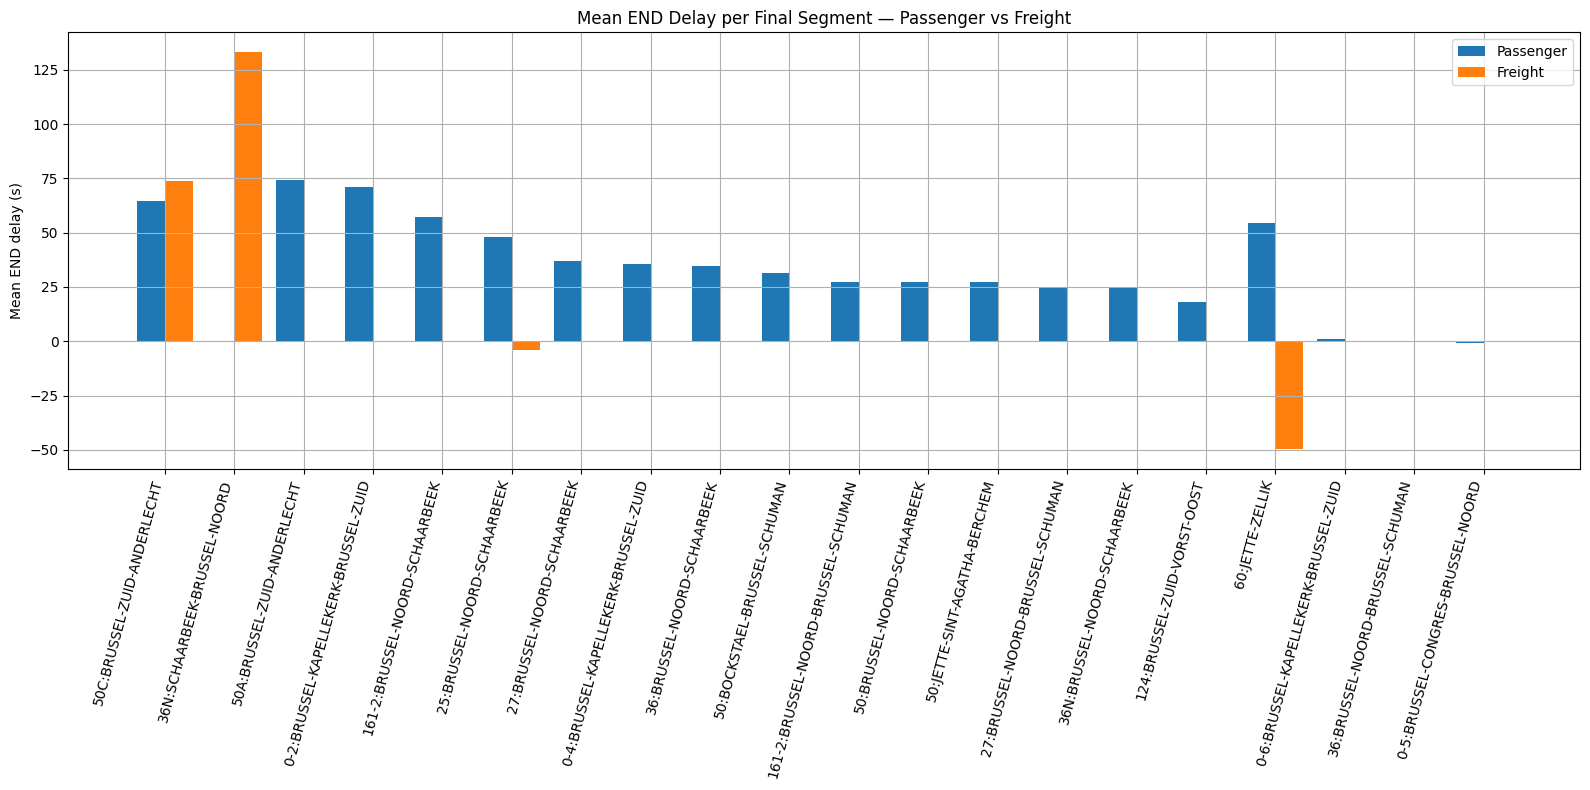

In [13]:
# ------------------------------------------------------------
# END DELAY PER SEGMENT (PASSENGER VS FREIGHT)
# ------------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# LAST SEGMENT PER TRAIN
# ============================================================

last_seg = (
    df.sort_values("planned_entry")
      .groupby(["train_id", "train_type"])
      .last()
      .reset_index()
)


# ============================================================
# MEAN END DELAY PER FINAL SEGMENT
# ============================================================

end_delay = (
    last_seg
    .groupby(["segment_id", "train_type"])["entry_delay"]
    .mean()
    .reset_index()
)

pivot = (
    end_delay
    .pivot(
        index="segment_id",
        columns="train_type",
        values="entry_delay"
    )
    .fillna(0)
)

pivot.columns.name = None

pivot = pivot.rename(columns={
    "P": "Passenger",
    "F": "Freight",
})

pivot["Combined"] = pivot.sum(axis=1)

pivot = (
    pivot
    .sort_values("Combined", ascending=False)
    .head(20)
)

print("==================================================")
print("TOP FINAL SEGMENTS BY MEAN END DELAY")
print("==================================================")

display(pivot)


# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(16, 8))

x = range(len(pivot))

width = 0.4

ax.bar(
    [i - width/2 for i in x],
    pivot["Passenger"],
    width=width,
    label="Passenger",
)

ax.bar(
    [i + width/2 for i in x],
    pivot["Freight"],
    width=width,
    label="Freight",
)

ax.set_xticks(list(x))

ax.set_xticklabels(
    pivot.index,
    rotation=75,
    ha="right"
)

ax.set_ylabel("Mean END delay (s)")
ax.set_title("Mean END Delay per Final Segment — Passenger vs Freight")

ax.legend()

ax.grid(True)

plt.tight_layout()
plt.show()

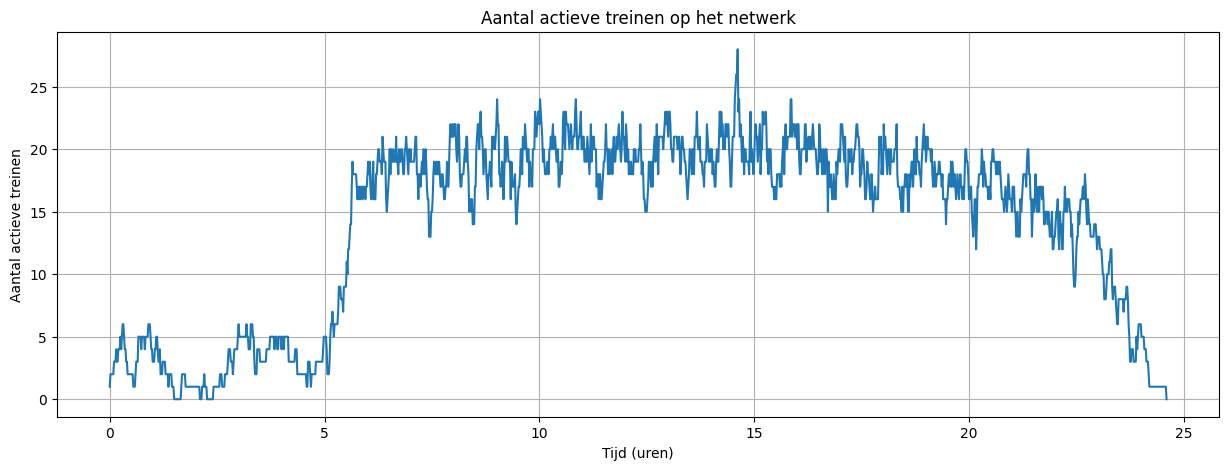

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Intervallen bepalen
# ============================================================

intervals = []

simulation_end = state.current_time

for train_id, seg_data in state._actual.items():

    entries = []
    exits   = []

    for seg_id, times in seg_data.items():

        entry, exit_ = times

        if entry is not None:
            entries.append(entry)

        if exit_ is not None:
            exits.append(exit_)

    if not entries:
        continue

    start = min(entries)

    if exits:
        end = max(exits)
    else:
        end = simulation_end

    intervals.append((start, end))

# ============================================================
# Tijdas (elke minuut)
# ============================================================

max_time = max(end for _, end in intervals)

times = np.arange(
    0,
    max_time + 60,
    60,  # 1 minuut resolutie
)

# ============================================================
# Actieve treinen tellen
# ============================================================

active_counts = []

for t in times:

    active = sum(
        start <= t <= end
        for start, end in intervals
    )

    active_counts.append(active)

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(15, 5))

plt.plot(
    times / 3600,
    active_counts,
)

plt.xlabel("Tijd (uren)")
plt.ylabel("Aantal actieve treinen")
plt.title("Aantal actieve treinen op het netwerk")

plt.grid(True)

plt.show()

In [15]:
print("Aantal treinen totaal:", len(state._trains))
print("Aantal treinen ooit gestart:", len(state._actual))
print("Aantal actieve treinen nu:", len(state.active_train_ids()))
max_active = max(active_counts)

print("Maximum simultaan actieve treinen:", max_active)

Aantal treinen totaal: 1210
Aantal treinen ooit gestart: 1210
Aantal actieve treinen nu: 0
Maximum simultaan actieve treinen: 28
